# Effect Estimation with DoWhy

Demonstrates all `causalts.effects` features on the **ex3** dataset (Cascade Network (11-Node), linear, max_lag=3).

**Features demonstrated:**
1. Graph discovery (CDNOTS)
2. Effect estimation
3. SCM fitting + counterfactual analysis
4. Root cause analysis
5. Graph falsification (no ground truth needed)
6. Structural refutation
7. Arrow strength + parent relevance
8. Distribution change detection (concept drift)

In [1]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import causalts.plotting as tp
from causalts.synthetic_data.synthetic_datasets import ex3
from causalts.effects import dowhy_available, print_effect_summary

print('DoWhy available:', dowhy_available())

DoWhy available: True


## 1. Load Cascade Network (ex3, d=11) and Discover Graph

In [2]:
result = ex3(seed=42, T=500)
df = result['df']
true_graph = result['ground_truth']
weights = result['weights']
var_names = df.columns.tolist()

print(f'ex3: {df.shape[1]} variables, T={len(df)}, max_lag={result["max_lag"]}')
print(f'Variables: {var_names}')
print(f'True edges: {int(true_graph.sum())}')

ex3: 11 variables, T=500, max_lag=3
Variables: ['Plcg', 'Pip3', 'Pip2', 'PKC', 'PKA', 'P38', 'Jnk', 'Raf', 'Mek', 'Erk', 'Akt']
True edges: 28


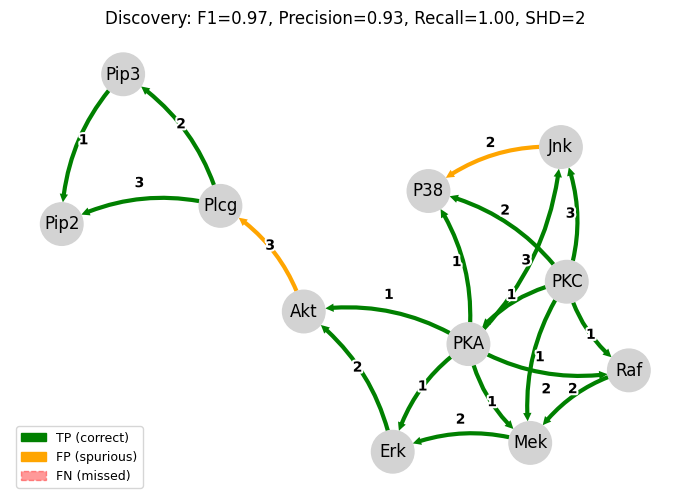

In [3]:
from causalts import run_cdnots
from causalts.ci_tests import PartialCorr
from causalts.utils import evaluate_graph

ci = PartialCorr(data=np.zeros((2, 2)))
_res = run_cdnots(
    df, ci, num_lags=3, include_C=False, alpha=0.05, stable=True
)
disc_graph = _res.cg_tig
graph = disc_graph  # alias for cells using old name
cg = _res  # CdnotsResult — carries plot/effect methods

m = evaluate_graph(disc_graph, true_graph)
pos = tp.compare_graphs(
    true_graph,
    disc_graph,
    var_names=var_names,
    figsize=(12, 6),
    node_layout="fdp",
    node_size=0.15,
    arrow_linewidth=3,
    fn_linewidth=2,
    fn_style="solid",
    return_pos=True,
    title=(
        f"Discovery: F1={m['F1']:.2f}, Precision={m['Precision']:.2f}, "
        f"Recall={m['TPR']:.2f}, SHD={m['SHD']}"
    ),
)

## 2. Effect Estimation

Estimate causal effects for key edges and compare to ground truth. Three columns:
- **True coeff** — the structural equation coefficient (direct effect only)
- **SCM coeff** — direct coefficient recovered by fitting a linear SCM to the discovered graph
- **ATE** — average treatment effect via DoWhy's backdoor criterion (includes all causal paths, direct + indirect)

In [ ]:
# Fit SCM first to extract direct coefficients
scm, dag, lagged_df = cg.fit_scm(mechanism_type='linear')

edges_to_test = [
    ('PKC', 'Raf', 1, weights[3, 7, 1]),   # PKC(t-1) -> Raf
    ('PKC', 'Mek', 1, weights[3, 8, 1]),   # PKC(t-1) -> Mek
    ('Raf', 'Mek', 2, weights[7, 8, 2]),   # Raf(t-2) -> Mek
    ('PKA', 'Erk', 1, weights[4, 9, 1]),   # PKA(t-1) -> Erk
    ('Erk', 'Akt', 2, weights[9, 10, 2]),  # Erk(t-2) -> Akt
    ('Plcg', 'Pip3', 2, weights[0, 1, 2]), # Plcg(t-2) -> Pip3
]

def get_scm_coeff(scm, parent_node, child_node):
    """Extract the linear coefficient from fitted SCM mechanism."""
    mechanism = scm.causal_mechanism(child_node)
    parents = sorted(dag.predecessors(child_node))
    parent_idx = parents.index(parent_node)
    return mechanism.prediction_model.sklearn_model.coef_.flatten()[parent_idx]

print(f'{"Edge":<22} {"True":>7} {"SCM":>8} {"ATE":>8}')
print(f'{"":22} {"coeff":>7} {"coeff":>8} {"(total)":>8}')
print('-' * 56)
for treat, out, lag, true_coeff in edges_to_test:
    parent_node = f'{treat}_lag{lag}' if lag > 0 else treat
    scm_coeff = get_scm_coeff(scm, parent_node, out)
    est = cg.estimate_effect(treat, out, treatment_lag=lag, confidence_intervals=False)
    print(f'{treat}(t-{lag}) -> {out:<10} {true_coeff:>8.3f} {scm_coeff:>8.3f} {est.value:>8.3f}')

print('\nNote: "True coeff" = structural equation coefficient (direct effect).')
print('      "SCM coeff"  = fitted direct effect from discovered graph.')
print('      "ATE"        = average treatment effect (all paths, direct + indirect).')

## 3. SCM Fitting + Counterfactual

Fit a structural causal model (cached), then ask: **What would Mek(t) be if PKC(t-1) were clamped to 0?**

SCM fitted: 44 nodes, 30 edges


Fitting causal mechanism of node Akt_lag3: 100%|██████████| 44/44 [00:00<00:00, 1870.27it/s]


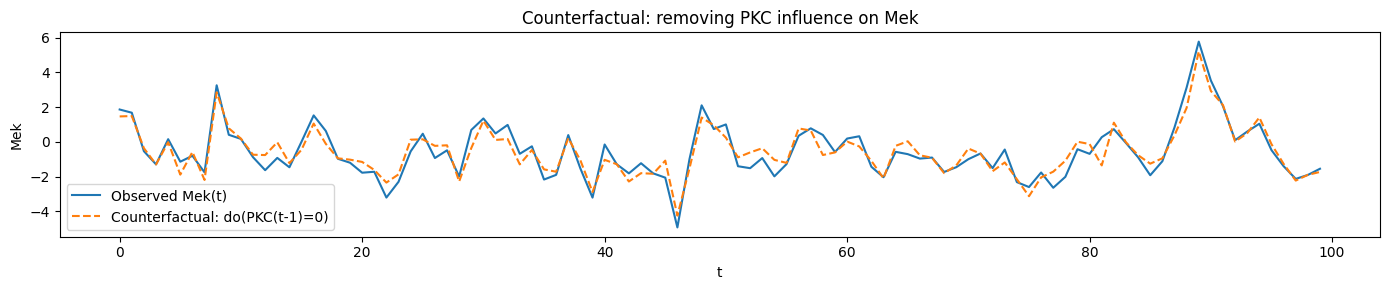

Variance of observed Mek:          2.9085
Variance of counterfactual Mek:    2.5057
Variance reduction from PKC(t-1):  13.9%

Mean shift is near zero (0.0071) because PKC is
zero-mean — it adds variance to Mek, not a directional bias.


In [5]:
# SCM already fitted above — just use the cached result
print(f'SCM fitted: {len(dag.nodes)} nodes, {len(dag.edges)} edges')

cf_mek = cg.counterfactual({'PKC_lag1': 0.0}, target='Mek')
observed_mek = lagged_df['Mek'].values

fig, ax = plt.subplots(figsize=(14, 3))
t = np.arange(100)
ax.plot(t, observed_mek[:100], label='Observed Mek(t)', lw=1.5)
ax.plot(t, cf_mek.values[:100], label='Counterfactual: do(PKC(t-1)=0)', lw=1.5, ls='--')
ax.set_xlabel('t'); ax.set_ylabel('Mek'); ax.legend()
ax.set_title('Counterfactual: removing PKC influence on Mek')
plt.tight_layout(); plt.show()

var_obs = np.var(observed_mek)
var_cf = np.var(cf_mek.values)
reduction = (var_obs - var_cf) / var_obs * 100
print(f'Variance of observed Mek:          {var_obs:.4f}')
print(f'Variance of counterfactual Mek:    {var_cf:.4f}')
print(f'Variance reduction from PKC(t-1):  {reduction:.1f}%')
print(f'\nMean shift is near zero ({observed_mek.mean() - cf_mek.values.mean():.4f}) because PKC is')
print('zero-mean — it adds variance to Mek, not a directional bias.')

## 4. Root Cause Analysis

Inject a sustained PKC anomaly and trace its root cause in Mek using Shapley-based attribution.

**How it works:** DoWhy's `attribute_anomaly` uses intrinsic causal contribution — it asks for each node in the graph: "if this node's noise had been different, would we still have observed the anomaly?" This traces through the **full causal graph**, not just direct parents.

**Generating a realistic anomaly:** We inject a spike into PKC for several time steps and re-simulate the system through the structural equations, so the effects propagate naturally (PKC spike → Raf/PKA affected at t+1 → Mek affected at t+2, etc.). The resulting observation is internally consistent.

**How to read the results:**
- Each node's **mean_attribution** shows how much its noise mechanism contributed to the anomaly in the target
- **Positive** = pushed the target higher than expected, **negative** = pushed it lower
- The node with the largest |attribution| is the root cause

PKC values in anomaly window (σ=1.07):
  PKC_lag3 = 7.00 (6.5σ)
  PKC_lag2 = 7.11 (6.6σ)
  PKC_lag1 = 1.89 (1.8σ)
  PKC      = 0.04 (0.0σ)
  Mek      = -1.69 (-1.0σ)


Evaluating set functions...: 100%|██████████| 32/32 [00:00<00:00, 379.18it/s]



Root cause attribution for Mek anomaly:
    node variable  lag  mean_attribution
PKA_lag1      PKA    1          0.919309
PKC_lag1      PKC    1          0.726267
     Mek      Mek    0         -0.436079
Raf_lag2      Raf    2         -0.316692
Mek_lag1      Mek    1          0.300642


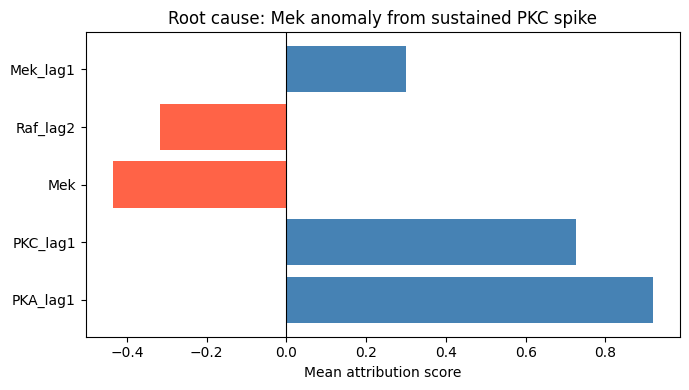


Attribution breakdown:
  PKA_lag1     +0.919  (34%)
  PKC_lag1     +0.726  (27%)
  Mek          -0.436  (16%)
  Raf_lag2     -0.317  (12%)
  Mek_lag1     +0.301  (11%)


In [6]:
# Generate a realistic anomaly by re-simulating with a PKC spike
# Use the same structural equations as ex3 but inject a 5σ spike in PKC's noise

rng_anom = np.random.default_rng(42)
maxlag = 3
T_anom = 20  # simulate a short window

# Start from a normal state (last few rows of original data)
x_orig = result['df'].values
x = np.zeros((T_anom + maxlag, 11))
x[:maxlag] = x_orig[-(maxlag):]  # seed with real data

# PKC spike: inject 5σ noise at time steps 3-6 (after the seed)
pkc_std = x_orig[:, 3].std()
spike_steps = range(maxlag, maxlag + 4)  # 4 consecutive time steps

for t in range(maxlag, T_anom + maxlag):
    noise = rng_anom.standard_normal(11) * 0.5
    # Inject PKC spike
    if t in spike_steps:
        noise[3] = 5 * pkc_std

    x[t, 0] = 0.9 * x[t-1, 0] + noise[0]
    x[t, 1] = 0.6 * x[t-1, 1] + 0.5 * x[t-2, 0] + noise[1]
    x[t, 2] = 0.4 * x[t-1, 2] + 0.4 * x[t-3, 0] + 0.3 * x[t-1, 1] + noise[2]
    x[t, 3] = 0.25 * x[t-1, 3] + noise[3]  # PKC — spiked noise here
    x[t, 4] = 0.25 * x[t-1, 4] - 0.25 * x[t-1, 3] + noise[4]
    x[t, 5] = 0.25 * x[t-1, 5] + 0.50 * x[t-2, 3] - 0.50 * x[t-1, 4] + noise[5]
    x[t, 6] = 0.30 * x[t-1, 6] - 0.25 * x[t-3, 3] + 0.25 * x[t-3, 4] + noise[6]
    x[t, 7] = 0.40 * x[t-1, 7] + 0.35 * x[t-1, 3] + 0.25 * x[t-2, 4] + noise[7]
    x[t, 8] = 0.50 * x[t-1, 8] - 0.5 * x[t-1, 3] + 0.25 * x[t-1, 4] + 0.6 * x[t-2, 7] + noise[8]
    x[t, 9] = 0.6 * x[t-1, 9] + 0.45 * x[t-1, 4] - 0.35 * x[t-2, 8] + noise[9]
    x[t, 10] = 0.7 * x[t-1, 10] - 0.25 * x[t-1, 4] + 0.25 * x[t-2, 9] + noise[10]

# Build the anomaly row for the lagged_df format (pick a time after propagation)
# At t = maxlag + 5 (two steps after the last spike), effects have propagated
t_obs = maxlag + 5
anomaly_dict = {}
for i, name in enumerate(var_names):
    anomaly_dict[name] = x[t_obs, i]
    for lag in range(1, maxlag + 1):
        anomaly_dict[f'{name}_lag{lag}'] = x[t_obs - lag, i]

anomaly_row = pd.Series(anomaly_dict)
# Reindex to match lagged_df columns
anomaly_row = anomaly_row.reindex(lagged_df.columns)

print(f'PKC values in anomaly window (σ={pkc_std:.2f}):')
print(f'  PKC_lag3 = {anomaly_row["PKC_lag3"]:.2f} ({anomaly_row["PKC_lag3"]/pkc_std:.1f}σ)')
print(f'  PKC_lag2 = {anomaly_row["PKC_lag2"]:.2f} ({anomaly_row["PKC_lag2"]/pkc_std:.1f}σ)')
print(f'  PKC_lag1 = {anomaly_row["PKC_lag1"]:.2f} ({anomaly_row["PKC_lag1"]/pkc_std:.1f}σ)')
print(f'  PKC      = {anomaly_row["PKC"]:.2f} ({anomaly_row["PKC"]/pkc_std:.1f}σ)')
print(f'  Mek      = {anomaly_row["Mek"]:.2f} ({anomaly_row["Mek"]/lagged_df["Mek"].std():.1f}σ)')

# Attribute the anomaly in Mek
attrs = cg.attribute_anomaly(anomaly_row, target='Mek', n_samples=2000)
print('\nRoot cause attribution for Mek anomaly:')
print(attrs.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if v >= 0 else 'tomato' for v in attrs['mean_attribution']]
ax.barh(attrs['node'], attrs['mean_attribution'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Mean attribution score')
ax.set_title('Root cause: Mek anomaly from sustained PKC spike')
plt.tight_layout(); plt.show()

# Summary
total_attr = attrs['mean_attribution'].abs().sum()
print('\nAttribution breakdown:')
for _, row in attrs.iterrows():
    pct = abs(row['mean_attribution']) / total_attr * 100
    sign = '+' if row['mean_attribution'] >= 0 else '-'
    print(f'  {row["node"]:<12} {sign}{abs(row["mean_attribution"]):.3f}  ({pct:.0f}%)')

## 5. Graph Falsification (no ground truth)

`cg.falsify()` tests if the discovered graph is "better than random" at capturing the data's independence structure. If `falsified=False`, the graph is consistent with the data.

In [7]:
result_f = cg.falsify()
print(f'Falsifiable: {result_f["falsifiable"]}')
print(f'Falsified:   {result_f["falsified"]}')
print()
if result_f['falsifiable'] and not result_f['falsified']:
    print('The graph is characteristic AND consistent with data.')
    print('-> No evidence against the discovered structure.')
elif result_f['falsified']:
    print('The graph FAILS the falsification test.')
    print('-> Some edges may be spurious or missing.')
else:
    print('The graph is not falsifiable (not characteristic enough).')

Falsifiable: True
Falsified:   False

The graph is characteristic AND consistent with data.
-> No evidence against the discovered structure.


## 6. Structural Refutation

`cg.refute_structure()` tests each node: are parents truly dependent? Is the node independent of non-descendants given parents?

In [8]:
refutation = cg.refute_structure()
print(f'Total tests: {len(refutation)}')
print(f'Rejected: {refutation["rejected"].sum()} / {len(refutation)}')
print()
rejected = refutation[refutation['rejected'] == True]
if len(rejected) > 0:
    print('Rejected structural assumptions:')
    print(rejected.to_string(index=False))
else:
    print('All structural assumptions hold.')

Total tests: 41
Rejected: 1 / 41

Rejected structural assumptions:
node variable  lag         test_type  rejected  p_value
 Mek      Mek    0 local_markov_test      True 0.040685


## 7. Arrow Strength + Parent Relevance

`cg.arrow_strength(target)` quantifies how strongly each parent influences the target.

`cg.parent_relevance(target)` ranks parents by Shapley-based explanatory power.

In [9]:
print('=== Arrow Strength: \u2192 Mek ===')
strengths = cg.arrow_strength('Mek')
print(strengths.to_string(index=False))

print()
print('=== Parent Relevance: Mek ===')
rel = cg.parent_relevance('Mek')
print(rel.to_string(index=False))

=== Arrow Strength: → Mek ===


Fitting causal mechanism of node Akt_lag3: 100%|██████████| 44/44 [00:00<00:00, 1980.29it/s]


parent_node variable  lag target  strength
   Mek_lag1      Mek    1    Mek  0.846742
   Raf_lag2      Raf    2    Mek  0.449339
   PKC_lag1      PKC    1    Mek  0.269048
   PKA_lag1      PKA    1    Mek  0.062617

=== Parent Relevance: Mek ===


Evaluating set functions...: 100%|██████████| 32/32 [00:00<00:00, 55.24it/s]


    node variable  lag  relevance_score
   noise    noise    0         0.910086
Mek_lag1      Mek    1         0.846669
Raf_lag2      Raf    2         0.431477
PKC_lag1      PKC    1         0.267384
PKA_lag1      PKA    1         0.044942


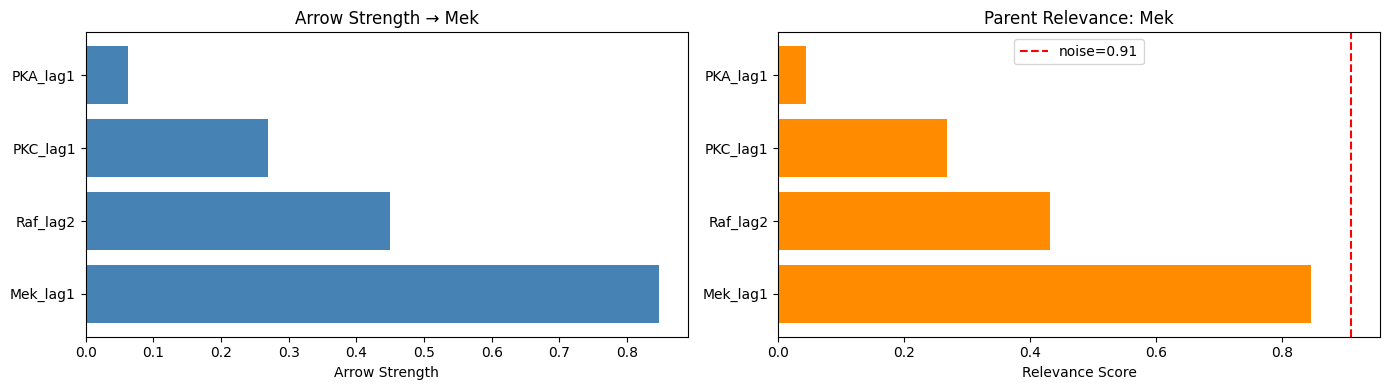

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(strengths['parent_node'], strengths['strength'], color='steelblue')
axes[0].set_xlabel('Arrow Strength')
axes[0].set_title('Arrow Strength \u2192 Mek')

rel_no_noise = rel[rel['node'] != 'noise']
axes[1].barh(rel_no_noise['node'], rel_no_noise['relevance_score'], color='darkorange')
noise_val = rel[rel['node'] == 'noise']['relevance_score'].values[0]
axes[1].axvline(noise_val, color='red', ls='--', label=f'noise={noise_val:.2f}')
axes[1].set_xlabel('Relevance Score')
axes[1].set_title('Parent Relevance: Mek')
axes[1].legend()

plt.tight_layout(); plt.show()

## 7b. Feature Relevance (Distribution and Sample-level)

Beyond `parent_relevance` (which uses the causal model), DoWhy provides two more flexible methods:

- **`feature_relevance_distribution`** — population-level: "How much does each feature contribute to the target's variance across all observations?"
- **`feature_relevance_sample`** — sample-level: "For this specific observation, how much did each feature shift the prediction away from the baseline?"

These work with any prediction function (not just the fitted SCM), so you can use them with the SCM's mechanism or any black-box model.

Mek's parents in DAG: ['Mek_lag1', 'PKA_lag1', 'PKC_lag1', 'Raf_lag2']


Evaluating set functions...: 100%|██████████| 16/16 [00:00<00:00, 33337.74it/s]



=== Distribution-level Feature Relevance (variance contribution to Mek) ===
Parent        Relevance  % of total
------------------------------------
Mek_lag1        -1.0220       51.4%
Raf_lag2        -0.5491       27.6%
PKC_lag1        -0.3359       16.9%
PKA_lag1        -0.0821        4.1%


Evaluating set functions...: 100%|██████████| 16/16 [00:00<00:00, 35639.33it/s]


=== Sample-level Feature Relevance (anomaly observation) ===
How much did each parent shift Mek for the anomalous row:
Parent            Shift
------------------------
Mek_lag1        -2.8888
Raf_lag2         2.0976
PKC_lag1        -0.9207
PKA_lag1        -0.4924


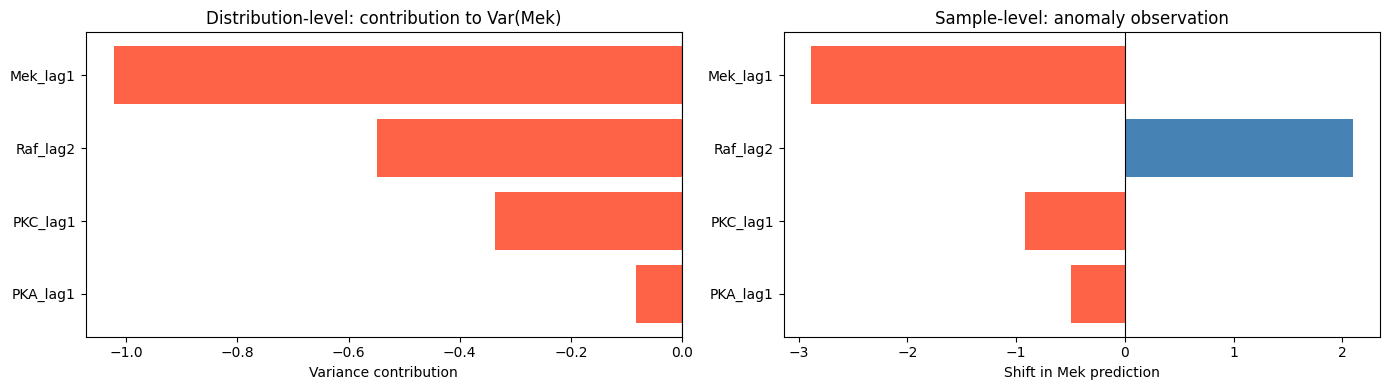


Interpretation:
  Left: Population-level — which parents drive Mek variability overall
  Right: Sample-level — which parents caused THIS specific Mek value to deviate


In [11]:
from dowhy import gcm

# Get Mek's prediction model from the fitted SCM
mek_mechanism = scm.causal_mechanism('Mek')
mek_parents = sorted(dag.predecessors('Mek'))
print(f"Mek's parents in DAG: {mek_parents}")

# Prepare parent data for Mek
parent_data = lagged_df[mek_parents].values

# --- Distribution-level relevance ---
# "How much does each parent contribute to Mek's overall variance?"
def variance_of_deviations(subset_preds, full_preds):
    return np.var(subset_preds - full_preds)

dist_relevance = gcm.feature_relevance_distribution(
    mek_mechanism.prediction_model.sklearn_model.predict,
    parent_data,
    subset_scoring_func=variance_of_deviations,
)

print('\n=== Distribution-level Feature Relevance (variance contribution to Mek) ===')
print(f'{"Parent":<12} {"Relevance":>10}  {"% of total":>10}')
print('-' * 36)
total = np.abs(dist_relevance).sum()
for name, rel in sorted(zip(mek_parents, dist_relevance), key=lambda x: abs(x[1]), reverse=True):
    print(f'{name:<12} {rel:>10.4f}  {abs(rel)/total*100:>9.1f}%')

# --- Sample-level relevance ---
# "For the anomalous observation, how much did each parent shift Mek?"
def means_difference(subset_preds, full_preds):
    return np.mean(subset_preds) - np.mean(full_preds)

# Use the anomaly row from section 4
anomaly_parents = anomaly_row[mek_parents].values.reshape(1, -1)

sample_relevance = gcm.feature_relevance_sample(
    mek_mechanism.prediction_model.sklearn_model.predict,
    parent_data,
    baseline_samples=anomaly_parents,
    subset_scoring_func=means_difference,
)

print('\n=== Sample-level Feature Relevance (anomaly observation) ===')
print('How much did each parent shift Mek for the anomalous row:')
print(f'{"Parent":<12} {"Shift":>10}')
print('-' * 24)
for name, rel in sorted(zip(mek_parents, sample_relevance[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f'{name:<12} {rel:>10.4f}')

# --- Visualize both ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution level
sorted_dist = sorted(zip(mek_parents, dist_relevance), key=lambda x: abs(x[1]))
names_d, vals_d = zip(*sorted_dist)
colors_d = ['steelblue' if v >= 0 else 'tomato' for v in vals_d]
axes[0].barh(names_d, vals_d, color=colors_d)
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel('Variance contribution')
axes[0].set_title('Distribution-level: contribution to Var(Mek)')

# Sample level
sorted_samp = sorted(zip(mek_parents, sample_relevance[0]), key=lambda x: abs(x[1]))
names_s, vals_s = zip(*sorted_samp)
colors_s = ['steelblue' if v >= 0 else 'tomato' for v in vals_s]
axes[1].barh(names_s, vals_s, color=colors_s)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlabel('Shift in Mek prediction')
axes[1].set_title('Sample-level: anomaly observation')

plt.tight_layout(); plt.show()

print('\nInterpretation:')
print('  Left: Population-level — which parents drive Mek variability overall')
print('  Right: Sample-level — which parents caused THIS specific Mek value to deviate')

## 8. Distribution Change Detection (Concept Drift)

`cg.distribution_change(data_new, target)` identifies which upstream mechanisms changed.

Two scenarios:
1. **Stationary split** (first half vs second half) — expect ~zero change
2. **Injected drift** — multiply PKC by 3 in the second half

In [12]:
n = len(df)

print('=== Scenario 1: Stationary split (expect near-zero) ===')
dc_stationary = cg.distribution_change(
    df.iloc[n//2:].reset_index(drop=True), target='Mek'
)
print(dc_stationary.to_string(index=False))
print(f'Max |contribution|: {dc_stationary["contribution"].abs().max():.4f}')

=== Scenario 1: Stationary split (expect near-zero) ===


Evaluating set functions...: 100%|██████████| 32/32 [00:00<00:00, 7373.39it/s]

    node variable  lag  contribution
Mek_lag1      Mek    1      0.018806
PKA_lag1      PKA    1     -0.014255
PKC_lag1      PKC    1     -0.013134
Raf_lag2      Raf    2      0.008632
     Mek      Mek    0     -0.000049
Max |contribution|: 0.0188


In [13]:
df_drifted = df.copy()
df_drifted.iloc[n//2:, df.columns.get_loc('PKC')] *= 3

print('=== Scenario 2: PKC mechanism changed (3x in 2nd half) ===')
dc_drift = cg.distribution_change(
    df_drifted.iloc[n//2:].reset_index(drop=True), target='Mek'
)
print(dc_drift.to_string(index=False))
print(f'\nTop contributor: {dc_drift.iloc[0]["node"]} '
      f'(contribution={dc_drift.iloc[0]["contribution"]:.4f})')

=== Scenario 2: PKC mechanism changed (3x in 2nd half) ===


Evaluating set functions...: 100%|██████████| 32/32 [00:00<00:00, 7582.92it/s]

    node variable  lag  contribution
     Mek      Mek    0      0.013715
PKA_lag1      PKA    1      0.006853
Mek_lag1      Mek    1      0.006567
PKC_lag1      PKC    1      0.006259
Raf_lag2      Raf    2     -0.000071

Top contributor: Mek (contribution=0.0137)


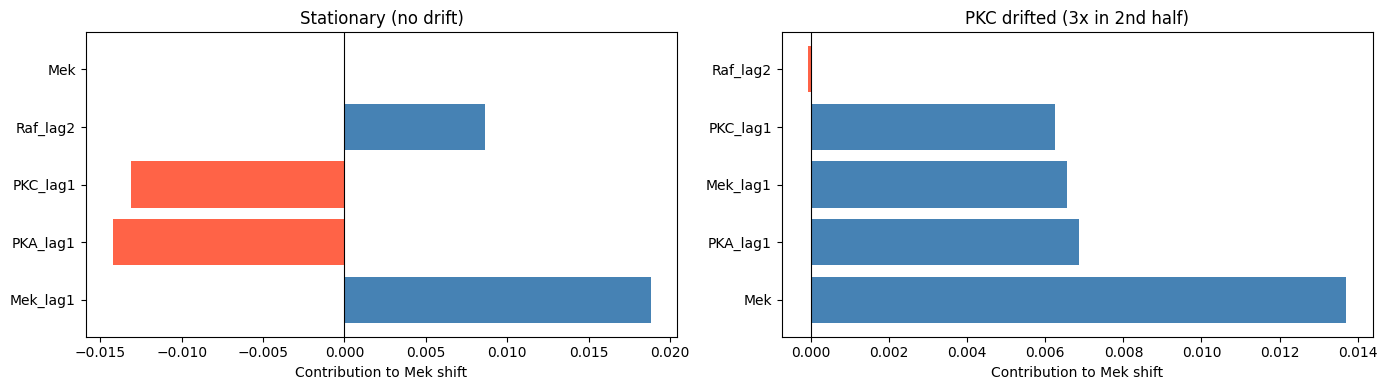

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (dc, title) in zip(axes, [
    (dc_stationary, 'Stationary (no drift)'),
    (dc_drift, 'PKC drifted (3x in 2nd half)'),
]):
    colors = ['steelblue' if v >= 0 else 'tomato' for v in dc['contribution']]
    ax.barh(dc['node'], dc['contribution'], color=colors)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Contribution to Mek shift')
    ax.set_title(title)
plt.tight_layout(); plt.show()

## 9. GRACE

ParCorrGPU requires CUDA; falling back to CPU PartialCorr


GraceResult(vars=11, edges=28, gate_threshold=0.5, lambda_l0=0.0572)

GRACE ATE PKC(t-1)->Mek: -0.6006
GRACE falsify: falsifiable=True, falsified=False


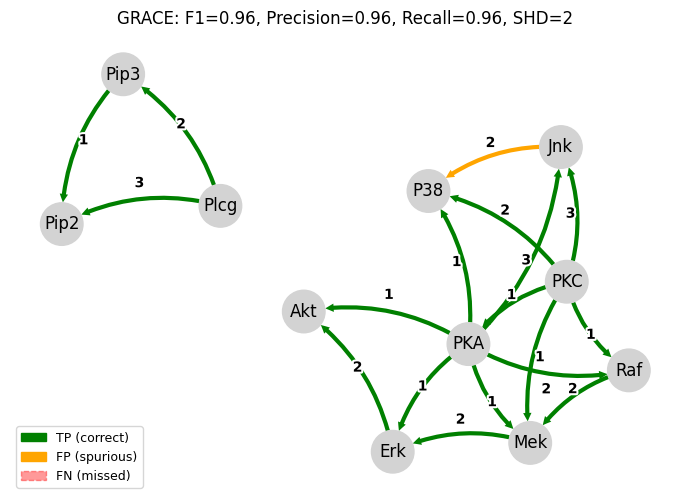

In [15]:
from causalts.grace import run_cdnots_gated

grace_res = run_cdnots_gated(df, max_lag=3, verbose=False)
G_hat = grace_res.cg_tig
print(grace_res)

m_g = evaluate_graph(G_hat, true_graph)
tp.compare_graphs(
    true_graph,
    G_hat,
    var_names=var_names,
    figsize=(12, 6),
    node_layout="fdp",
    node_size=0.15,
    arrow_linewidth=3,
    fn_linewidth=2,
    fn_style="solid",
    node_pos=pos[2],
    title=(
        f"GRACE: F1={m_g['F1']:.2f}, Precision={m_g['Precision']:.2f}, "
        f"Recall={m_g['TPR']:.2f}, SHD={m_g['SHD']}"
    ),
)

est_g = grace_res.estimate_effect(
    "PKC", "Mek", treatment_lag=1, confidence_intervals=False
)
print(f"\nGRACE ATE PKC(t-1)->Mek: {est_g.value:.4f}")

result_fg = grace_res.falsify()
print(
    f"GRACE falsify: falsifiable={result_fg['falsifiable']}, "
    f"falsified={result_fg['falsified']}"
)

## Summary

| Feature | Method | Ground truth? |
|---|---|---|
| Effect estimation | `cg.estimate_effect(treat, out, lag)` | No |
| SCM fitting (cached) | `cg.fit_scm()` | No |
| Counterfactual | `cg.counterfactual({node: val}, target)` | No |
| Interventional query | `cg.interventional_query({var: val}, targets)` | No |
| Observational query | `cg.observational_query({var: val}, targets)` | No |
| Root cause | `cg.attribute_anomaly(row, target)` | No |
| Graph falsification | `cg.falsify()` | No |
| Structural refutation | `cg.refute_structure()` | No |
| Arrow strength | `cg.arrow_strength(target)` | No |
| Parent relevance | `cg.parent_relevance(target)` | No |
| Distribution change | `cg.distribution_change(df_new, target)` | No |

All methods work on `run_cdnots` / `run_cdnots_plus` (via `CdnotsResult`), `run_cedar` (via `CedarResult`), and `run_cdnots_gated` (via `GraceResult`) — all result objects inherit effect-estimation methods automatically.

See [Probabilistic Queries notebook](probabilistic_queries.ipynb) for full interventional/observational query examples.

Install: `pip install causalts[dowhy]`

## 10. Direct and Mediated Effects via Tigramite

The DoWhy bridge (section 2) estimates the *average treatment effect* (ATE) -- total
causal effect pooling all paths. Tigramite's Wright path method decomposes this by
**pathway**: what fraction of the effect travels directly vs through each mediator.

In time series, mediation is inherently **lag-specific**: the direct edge PKC(t-1)->Mek(t)
operates at lag 1, while the mediated path PKC(t-2)->PKA(t-1)->Mek(t) needs lag 2.
`pathwise_effects()` automatically discovers all directed paths and their lag requirements.

Requires `pip install tigramite`.

In [16]:
from causalts.effects.tigramite_effects import pathwise_effects

# Automatically find all paths from PKC to Mek and decompose effects
result = pathwise_effects(disc_graph, df, "PKC", "Mek", var_names=var_names)

print(f"Found {len(result['paths'])} paths from PKC to Mek:")
print()
for p in result["paths"]:
    print(f"  {p['route']}  (edge lags: {p['edge_lags']}, total_lag={p['total_lag']})")

print(f"\nEffect by lag horizon:")
for lag, info in sorted(result["by_lag"].items()):
    routes = ", ".join(p["route"] for p in info["paths"])
    share = result["shares"].get(lag, 0)
    print(f"  Lag {lag}: effect={info['effect']:+.4f}  share={share:.1%}  ({routes})")

print(f"\nCumulative total: {result['cumulative']:+.4f}")

Found 4 paths from PKC to Mek:

  PKC → Mek  (edge lags: [1], total_lag=1)
  PKC → PKA → Mek  (edge lags: [1, 1], total_lag=2)
  PKC → Raf → Mek  (edge lags: [1, 2], total_lag=3)
  PKC → PKA → Raf → Mek  (edge lags: [1, 2, 2], total_lag=5)

Effect by lag horizon:
  Lag 1: effect=-0.4835  share=44.9%  (PKC → Mek)
  Lag 2: effect=-0.4382  share=40.7%  (PKC → PKA → Mek)
  Lag 3: effect=-0.0826  share=7.7%  (PKC → Raf → Mek)
  Lag 5: effect=+0.0720  share=6.7%  (PKC → PKA → Raf → Mek)

Cumulative total: -0.9323


| Method | API | What it gives |
|--------|-----|---------------|
| DoWhy ATE | `estimate_effect()` | Average treatment effect (all paths pooled) |
| Tigramite total | `TigramiteEffects(X_lag=k).total_effect()` | Total at a specific lag horizon |
| Tigramite direct | `.direct_effect()` | Direct edge only, no mediation |
| Pathway decomposition | `pathwise_effects(graph, df, X, Y)` | All paths auto-discovered, per-path effects and % shares |